# 03_extract_audio_features.ipynb — ANTI-OVERFITTING EDITION

## Purpose
Extracts a **rich but controlled** acoustic feature set to support robust audio classification.

### Anti-overfitting additions over baseline:
| Addition | Why it matters |
|---|---|
| **Correlation pruning** (threshold ≥ 0.95) | 400+ raw features include many redundant pairs (mel bands, delta variants) — redundancy inflates dimensionality without adding signal, worsening overfitting downstream |
| **Variance filter** | Removes near-zero-variance features that carry no signal |
| **Feature count report** | Explicit log so downstream notebooks know what they receive |

Output: `data/processed/audio_features_dataset.csv`


## 1. Install required packages (if needed)

In [ ]:
# Uncomment if needed:
# !pip install librosa soundfile audioread numpy pandas matplotlib tqdm scikit-learn joblib

## 2. Import required libraries

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import librosa
import librosa.display

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 100)

print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('librosa:', librosa.__version__)


numpy: 2.4.4
pandas: 3.0.2
librosa: 0.11.0


## 3. Set paths

In [2]:
TRANSCRIPT_DATASET_PATH = Path('data/processed/transcripts_dataset.csv')
OUTPUT_DIR  = Path('data/processed')
REPORT_DIR  = Path('reports')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_FEATURES_OUTPUT_PATH = OUTPUT_DIR / 'audio_features_dataset.csv'

print('Transcript dataset exists:', TRANSCRIPT_DATASET_PATH.exists())
print('Output path:', AUDIO_FEATURES_OUTPUT_PATH.resolve())


Transcript dataset exists: True
Output path: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\data\processed\audio_features_dataset.csv


## 4. Load transcript dataset and validate audio paths

In [11]:
if not TRANSCRIPT_DATASET_PATH.exists():
    raise FileNotFoundError('Run 01_parse_cha_files.ipynb first.')

df = pd.read_csv(TRANSCRIPT_DATASET_PATH)
df['audio_path'] = df['audio_path'].astype(str)
df['audio_exists_checked'] = df['audio_path'].apply(lambda p: Path(p).exists())

print('Dataset shape:', df.shape)
print('Audio files found:', df['audio_exists_checked'].sum(), '/', len(df))
display(df[['file_id','label','label_id','audio_path','audio_exists_checked']].head())

df_audio = df[df['audio_exists_checked'] == True].copy()
print('Valid audio dataset shape:', df_audio.shape)


Dataset shape: (552, 23)
Audio files found: 552 / 552


,file_id,label,label_id,audio_path,audio_exists_checked
0,002-0,Control,0,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-0.mp3,True
1,002-1,Control,0,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-1.mp3,True
2,002-2,Control,0,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-2.mp3,True
3,002-3,Control,0,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-3.mp3,True
4,006-2,Control,0,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\006-2.mp3,True


Valid audio dataset shape: (552, 23)


## 5. Audio loading settings

In [4]:
TARGET_SR    = 16000
N_MFCC       = 40
N_MELS       = 128
HOP_LENGTH   = 512
FRAME_LENGTH = 2048
N_CHROMA     = 12

# Anti-overfitting: correlation threshold for feature pruning (applied after extraction)
CORR_THRESHOLD = 0.95

print('Target sample rate :', TARGET_SR)
print('Number of MFCCs    :', N_MFCC)
print('Number of mel bands:', N_MELS)
print('Correlation pruning threshold:', CORR_THRESHOLD,
      '— removes redundant feature pairs to reduce dimensionality')


Target sample rate : 16000
Number of MFCCs    : 40
Number of mel bands: 128
Correlation pruning threshold: 0.95 — removes redundant feature pairs to reduce dimensionality


## 6. Test load one audio file

In [5]:
if df_audio.empty:
    raise ValueError('No valid audio files found. Check audio paths.')

sample_audio_path = Path(df_audio.iloc[0]['audio_path'])
y_sample, sr_sample = librosa.load(sample_audio_path, sr=TARGET_SR, mono=True)
print('Sample audio:', sample_audio_path.name)
print('Duration:', round(librosa.get_duration(y=y_sample, sr=sr_sample), 2), 'sec')
print('Shape:', y_sample.shape)


Sample audio: 002-0.mp3
Duration: 62.74 sec
Shape: (1003864,)


## 7. Visualize sample waveform

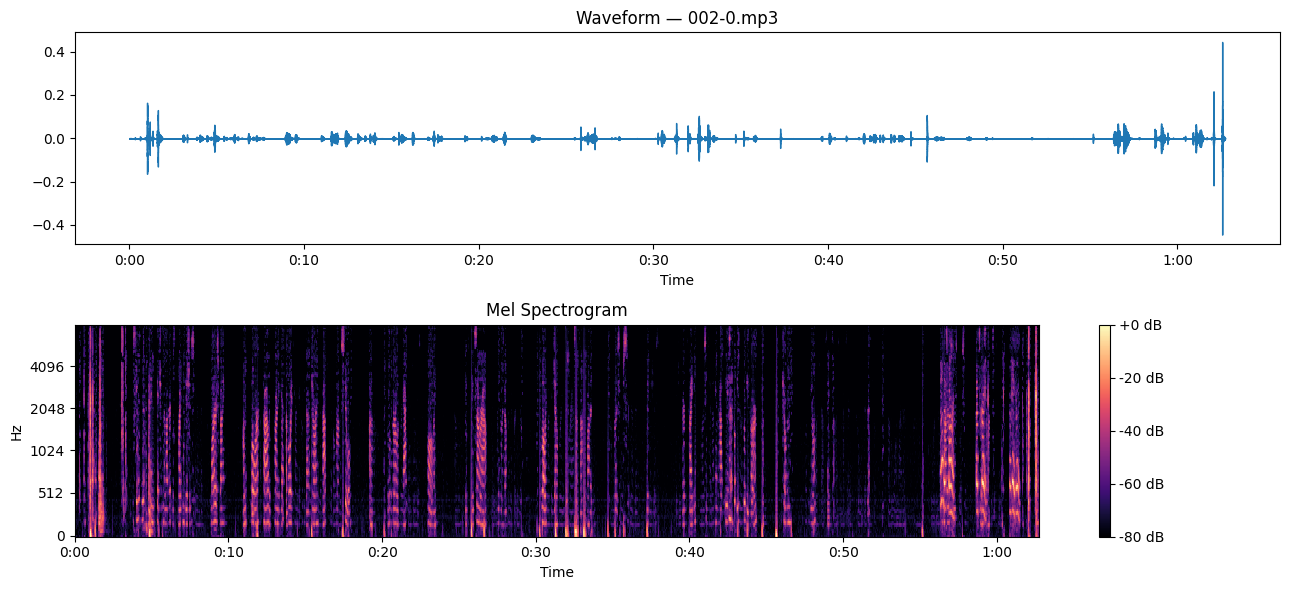

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

librosa.display.waveshow(y_sample, sr=sr_sample, ax=axes[0])
axes[0].set_title(f'Waveform — {sample_audio_path.name}')

S = librosa.feature.melspectrogram(y=y_sample, sr=sr_sample, n_mels=N_MELS)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr_sample, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mel Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()


## 8. Enhanced Feature Helper Functions

In [7]:
def summarize_array(values, prefix):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {f'{prefix}_{s}': np.nan for s in ['mean','std','min','max','median','p25','p75','iqr']}
    return {
        f'{prefix}_mean'  : float(np.mean(values)),
        f'{prefix}_std'   : float(np.std(values)),
        f'{prefix}_min'   : float(np.min(values)),
        f'{prefix}_max'   : float(np.max(values)),
        f'{prefix}_median': float(np.median(values)),
        f'{prefix}_p25'   : float(np.percentile(values, 25)),
        f'{prefix}_p75'   : float(np.percentile(values, 75)),
        f'{prefix}_iqr'   : float(np.percentile(values, 75) - np.percentile(values, 25)),
    }


def estimate_pause_features(y, sr, frame_length=2048, hop_length=512, top_db=30):
    duration = librosa.get_duration(y=y, sr=sr)
    if duration <= 0:
        return {
            'non_silent_duration_sec': 0, 'silent_duration_sec': 0,
            'speech_ratio': 0, 'pause_ratio': 1,
            'num_non_silent_segments': 0, 'avg_non_silent_segment_sec': 0,
            'num_pauses': 0, 'avg_pause_duration_sec': 0,
            'pause_duration_std': 0, 'max_pause_duration_sec': 0,
            'speaking_rate_segments_per_min': 0,
        }

    intervals = librosa.effects.split(y, top_db=top_db,
                                       frame_length=frame_length, hop_length=hop_length)
    if len(intervals) == 0:
        return {
            'non_silent_duration_sec': 0, 'silent_duration_sec': float(duration),
            'speech_ratio': 0, 'pause_ratio': 1,
            'num_non_silent_segments': 0, 'avg_non_silent_segment_sec': 0,
            'num_pauses': 0, 'avg_pause_duration_sec': float(duration),
            'pause_duration_std': 0, 'max_pause_duration_sec': float(duration),
            'speaking_rate_segments_per_min': 0,
        }

    seg_lengths = (intervals[:, 1] - intervals[:, 0]) / sr
    non_silent_duration = float(np.sum(seg_lengths))
    silent_duration = max(0, duration - non_silent_duration)

    pause_durations = []
    for i in range(1, len(intervals)):
        gap = (intervals[i, 0] - intervals[i-1, 1]) / sr
        if gap > 0.05:
            pause_durations.append(gap)

    num_pauses = len(pause_durations)
    return {
        'non_silent_duration_sec'       : float(non_silent_duration),
        'silent_duration_sec'           : float(silent_duration),
        'speech_ratio'                  : float(non_silent_duration / duration),
        'pause_ratio'                   : float(silent_duration / duration),
        'num_non_silent_segments'       : int(len(seg_lengths)),
        'avg_non_silent_segment_sec'    : float(np.mean(seg_lengths)),
        'num_pauses'                    : num_pauses,
        'avg_pause_duration_sec'        : float(np.mean(pause_durations)) if pause_durations else 0,
        'pause_duration_std'            : float(np.std(pause_durations))  if pause_durations else 0,
        'max_pause_duration_sec'        : float(np.max(pause_durations))  if pause_durations else 0,
        'speaking_rate_segments_per_min': float(len(seg_lengths) / duration * 60) if duration > 0 else 0,
    }


def extract_pitch_features(y, sr, frame_length=2048, hop_length=512):
    try:
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y,
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            sr=sr,
            frame_length=frame_length,
            hop_length=hop_length,
        )
        voiced_f0 = f0[np.isfinite(f0)]
        pitch_stats = summarize_array(voiced_f0, 'pitch_f0')
        pitch_stats['voiced_frame_ratio']      = float(np.mean(voiced_flag)) if voiced_flag is not None else np.nan
        pitch_stats['voiced_probability_mean'] = float(np.nanmean(voiced_probs)) if voiced_probs is not None else np.nan
        if len(voiced_f0) > 1:
            pitch_stats['pitch_f0_range'] = float(np.max(voiced_f0) - np.min(voiced_f0))
            pitch_stats['pitch_f0_cv']    = float(np.std(voiced_f0) / np.mean(voiced_f0)) if np.mean(voiced_f0) > 0 else 0
        else:
            pitch_stats['pitch_f0_range'] = np.nan
            pitch_stats['pitch_f0_cv']    = np.nan
        return pitch_stats
    except Exception:
        return {k: np.nan for k in [
            'pitch_f0_mean','pitch_f0_std','pitch_f0_min','pitch_f0_max',
            'pitch_f0_median','pitch_f0_p25','pitch_f0_p75','pitch_f0_iqr',
            'voiced_frame_ratio','voiced_probability_mean','pitch_f0_range','pitch_f0_cv'
        ]}


def estimate_jitter_shimmer(y, sr, hop_length=512):
    try:
        rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
        rms_nz = rms[rms > 1e-6]
        shimmer_approx = float(np.mean(np.abs(np.diff(rms_nz))) / np.mean(rms_nz)) if len(rms_nz) > 1 else np.nan
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)[0]
        jitter_approx = float(np.std(zcr) / np.mean(zcr)) if np.mean(zcr) > 0 else np.nan
        return {'shimmer_approx': shimmer_approx, 'jitter_approx': jitter_approx}
    except Exception:
        return {'shimmer_approx': np.nan, 'jitter_approx': np.nan}


def extract_spectral_flux(y, sr, hop_length=512):
    try:
        stft = np.abs(librosa.stft(y, hop_length=hop_length))
        flux = np.sqrt(np.sum(np.diff(stft, axis=1) ** 2, axis=0))
        return summarize_array(flux, 'spectral_flux')
    except Exception:
        return {f'spectral_flux_{s}': np.nan for s in ['mean','std','min','max','median','p25','p75','iqr']}


print('Helper functions defined.')


Helper functions defined.


## 9. Main Feature Extraction Function

In [8]:
def extract_audio_features(audio_path, target_sr=16000, use_pitch=True):
    audio_path = Path(audio_path)
    features = {'audio_load_success': False, 'audio_error': None}

    try:
        y, sr = librosa.load(audio_path, sr=target_sr, mono=True)

        y_trimmed, _ = librosa.effects.trim(y, top_db=35)
        if len(y_trimmed) > sr * 0.5:
            y = y_trimmed

        duration = librosa.get_duration(y=y, sr=sr)
        features.update({
            'audio_load_success': True,
            'sample_rate'       : sr,
            'duration_sec'      : float(duration),
            'num_samples'       : int(len(y)),
        })

        # 1. RMS energy
        rms = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(rms, 'rms_energy'))
        features['rms_energy_p10']     = float(np.percentile(rms[rms > 1e-8], 10)) if np.any(rms > 1e-8) else 0
        features['rms_energy_p90']     = float(np.percentile(rms, 90))
        features['rms_dynamic_range']  = features['rms_energy_p90'] - features['rms_energy_p10']

        # 2. Zero-crossing rate
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(zcr, 'zero_crossing_rate'))

        # 3. Spectral features
        sc = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(sc, 'spectral_centroid'))
        sb = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(sb, 'spectral_bandwidth'))
        sr_ = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(sr_, 'spectral_rolloff'))
        sf = librosa.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)[0]
        features.update(summarize_array(sf, 'spectral_flatness'))
        features.update(extract_spectral_flux(y, sr, HOP_LENGTH))

        try:
            contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH)
            for i in range(contrast.shape[0]):
                features[f'spectral_contrast_{i+1}_mean'] = float(np.mean(contrast[i]))
                features[f'spectral_contrast_{i+1}_std']  = float(np.std(contrast[i]))
        except Exception:
            pass

        # 4. MFCCs (40 coefficients × mean/std/median)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        for i in range(N_MFCC):
            features[f'mfcc_{i+1}_mean']   = float(np.mean(mfcc[i]))
            features[f'mfcc_{i+1}_std']    = float(np.std(mfcc[i]))
            features[f'mfcc_{i+1}_median'] = float(np.median(mfcc[i]))

        # 5. MFCC Delta
        mfcc_delta = librosa.feature.delta(mfcc)
        for i in range(N_MFCC):
            features[f'mfcc_delta_{i+1}_mean'] = float(np.mean(mfcc_delta[i]))
            features[f'mfcc_delta_{i+1}_std']  = float(np.std(mfcc_delta[i]))

        # 6. MFCC Delta-Delta
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        for i in range(N_MFCC):
            features[f'mfcc_delta2_{i+1}_mean'] = float(np.mean(mfcc_delta2[i]))
            features[f'mfcc_delta2_{i+1}_std']  = float(np.std(mfcc_delta2[i]))

        # 7. Mel-spectrogram — group into 4 bands to limit raw dimensionality
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db   = librosa.power_to_db(mel_spec, ref=np.max)
        group_size = N_MELS // 4
        for g in range(4):
            band = mel_db[g*group_size:(g+1)*group_size, :].ravel()
            features[f'mel_band_g{g+1}_mean'] = float(np.mean(band))
            features[f'mel_band_g{g+1}_std']  = float(np.std(band))
        mel_band_means = mel_db.mean(axis=1)
        features.update(summarize_array(mel_band_means, 'mel_band_profile'))

        # 8. Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)
        for i in range(chroma.shape[0]):
            features[f'chroma_{i+1}_mean'] = float(np.mean(chroma[i]))
            features[f'chroma_{i+1}_std']  = float(np.std(chroma[i]))

        # 9. Tonnetz
        try:
            y_harmonic = librosa.effects.harmonic(y)
            tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
            for i in range(tonnetz.shape[0]):
                features[f'tonnetz_{i+1}_mean'] = float(np.mean(tonnetz[i]))
                features[f'tonnetz_{i+1}_std']  = float(np.std(tonnetz[i]))
        except Exception:
            for i in range(6):
                features[f'tonnetz_{i+1}_mean'] = np.nan
                features[f'tonnetz_{i+1}_std']  = np.nan

        # 10. Pause/silence analysis
        features.update(estimate_pause_features(y, sr, FRAME_LENGTH, HOP_LENGTH))

        # 11. Jitter/shimmer approximation
        features.update(estimate_jitter_shimmer(y, sr, HOP_LENGTH))

        # 12. Pitch/F0
        if use_pitch:
            features.update(extract_pitch_features(y, sr, FRAME_LENGTH, HOP_LENGTH))

    except Exception as e:
        features['audio_error'] = str(e)

    return features

print('Main extraction function defined.')


Main extraction function defined.


## 10. Test feature extraction on one file

In [9]:
sample_feats = extract_audio_features(sample_audio_path, target_sr=TARGET_SR, use_pitch=True)
print('Number of extracted fields:', len(sample_feats))
print('Load success:', sample_feats.get('audio_load_success'))
print('Duration:', sample_feats.get('duration_sec'))

feat_series = pd.Series(sample_feats)
print('\nFeature preview (first 60):')
display(feat_series.head(60).to_frame('value'))


Number of extracted fields: 435
Load success: True
Duration: 62.1655

Feature preview (first 60):


,value
audio_load_success,True
audio_error,None
sample_rate,16000
duration_sec,62.1655
num_samples,994648
rms_energy_mean,0.002217
rms_energy_std,0.004926
rms_energy_min,0.000033
rms_energy_max,0.043157
rms_energy_median,0.000137


## 11. Extract features for all audio files

In [10]:
USE_PITCH = True

rows = []
for _, row in tqdm(df_audio.iterrows(), total=len(df_audio), desc='Extracting audio features'):
    audio_path = Path(row['audio_path'])
    features   = extract_audio_features(audio_path, target_sr=TARGET_SR, use_pitch=USE_PITCH)
    metadata   = {
        'file_id'    : row.get('file_id'),
        'label'      : row.get('label'),
        'label_id'   : row.get('label_id'),
        'age'        : row.get('age', np.nan),
        'sex'        : row.get('sex', np.nan),
        'mmse'       : row.get('mmse', np.nan),
        'word_count' : row.get('word_count', np.nan),
        'transcript' : row.get('transcript', ''),
        'audio_path' : str(audio_path),
    }
    rows.append({**metadata, **features})

audio_features_df = pd.DataFrame(rows)
print('Raw audio features dataset shape:', audio_features_df.shape)
display(audio_features_df.head())


Extracting audio features:   0%|          | 0/552 [00:00<?, ?it/s]

Raw audio features dataset shape: (552, 444)


,file_id,label,label_id,age,sex,mmse,word_count,transcript,audio_path,audio_load_success,audio_error,sample_rate,duration_sec,num_samples,rms_energy_mean,rms_energy_std,rms_energy_min,rms_energy_max,rms_energy_median,rms_energy_p25,rms_energy_p75,rms_energy_iqr,rms_energy_p10,rms_energy_p90,rms_dynamic_range,zero_crossing_rate_mean,zero_crossing_rate_std,zero_crossing_rate_min,zero_crossing_rate_max,zero_crossing_rate_median,zero_crossing_rate_p25,zero_crossing_rate_p75,zero_crossing_rate_iqr,spectral_centroid_mean,spectral_centroid_std,spectral_centroid_min,spectral_centroid_max,spectral_centroid_median,spectral_centroid_p25,spectral_centroid_p75,spectral_centroid_iqr,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_bandwidth_min,spectral_bandwidth_max,spectral_bandwidth_median,spectral_bandwidth_p25,spectral_bandwidth_p75,spectral_bandwidth_iqr,spectral_rolloff_mean,...,chroma_6_std,chroma_7_mean,chroma_7_std,chroma_8_mean,chroma_8_std,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,tonnetz_1_mean,tonnetz_1_std,tonnetz_2_mean,tonnetz_2_std,tonnetz_3_mean,tonnetz_3_std,tonnetz_4_mean,tonnetz_4_std,tonnetz_5_mean,tonnetz_5_std,tonnetz_6_mean,tonnetz_6_std,non_silent_duration_sec,silent_duration_sec,speech_ratio,pause_ratio,num_non_silent_segments,avg_non_silent_segment_sec,num_pauses,avg_pause_duration_sec,pause_duration_std,max_pause_duration_sec,speaking_rate_segments_per_min,shimmer_approx,jitter_approx,pitch_f0_mean,pitch_f0_std,pitch_f0_min,pitch_f0_max,pitch_f0_median,pitch_f0_p25,pitch_f0_p75,pitch_f0_iqr,voiced_frame_ratio,voiced_probability_mean,pitch_f0_range,pitch_f0_cv
0,002-0,Control,0,58.0,female,30.0,178,the scene is in the in the kitchen 3754 5640 the mother is wiping dishes and the water is running on the floor 5776 ...,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-0.mp3,True,None,16000,62.1655,994648,0.002217,0.004926,0.000033,0.043157,0.000137,0.000056,0.002253,0.002197,0.000039,0.005850,0.005811,0.226185,0.104035,0.007812,0.816406,0.224609,0.148682,0.293945,0.145264,2264.675975,900.955175,277.099605,6324.166785,2378.948490,1521.566426,2788.460553,1266.894127,2004.902657,474.273193,728.187335,3283.183430,2233.911725,1680.436499,2350.117674,669.681175,4598.140762,...,0.301627,0.513482,0.318710,0.460025,0.301840,0.461699,0.308738,0.504088,0.360093,0.436265,0.308781,0.443769,0.324990,0.004103,0.084488,-0.027142,0.083963,0.021559,0.144111,0.010073,0.144239,0.000966,0.045359,0.013743,0.051088,19.7015,42.464,0.316920,0.683080,73,0.269884,62,0.674065,0.962541,6.912,70.457086,0.316354,0.459956,160.632050,62.677415,65.406391,455.516566,163.864521,118.922487,181.033669,62.111182,0.471436,0.083640,390.110175,0.390192
1,002-1,Control,0,59.0,female,30.0,122,oh i see the sink is running over 3044 5547 i see the stool is tipping over 7371 9595 little boy's trying to get coo...,C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\data\raw\Pitt\Control\cookie\002-1.mp3,True,None,16000,77.6655,1242648,0.003334,0.004881,0.000068,0.053899,0.001666,0.000133,0.004707,0.004575,0.000087,0.008266,0.008179,0.190783,0.116577,0.025391,0.773438,0.164551,0.117188,0.213379,0.096191,2123.688359,1000.144809,449.047241,6152.455359,1966.971636,1458.879218,2390.330552,931.451334,1827.194233,399.254520,701.799231,3017.038602,1922.600557,1523.849454,2119.545780,595.696326,4109.912351,...,0.321127,0.406700,0.314041,0.369257,0.287475,0.389908,0.307103,0.405072,0.324283,0.387150,0.323239,0.405011,0.329926,0.031706,0.083499,-0.013073,0.084280,-0.005485,0.124419,-0.007850,0.146355,-0.007348,0.047168,-0.002168,0.051633,38.5295,39.136,0.496095,0.503905,80,0.481619,70,0.554057,0.726065,3.488,61.803503,0.207372,0.611047,178.982803,142.584174,65.406391,1770.195576,168.666118,139.193454,208.855267,69.661813,0.390445,0.074976,1704.789185,0.796636
2,002-2,Control,0,60.0,female,30.0,181,a boy and a 

## 12. Validate and clean

In [12]:
print('Load success distribution:')
display(audio_features_df['audio_load_success'].value_counts(dropna=False))

success_df = audio_features_df[audio_features_df['audio_load_success'] == True].copy()
print('\nSuccessfully processed:', len(success_df))
print('Label distribution:')
display(success_df['label'].value_counts())

audio_features_clean = success_df.replace([np.inf, -np.inf], np.nan).copy()
audio_features_clean['label_id'] = pd.to_numeric(audio_features_clean['label_id'], errors='coerce').astype(int)

numeric_cols = audio_features_clean.select_dtypes(include=[np.number]).columns.tolist()
missing_pct  = audio_features_clean[numeric_cols].isna().mean().sort_values(ascending=False)
print('\nTop missing features:')
display(missing_pct.head(20))
print('\nTotal numeric features (raw):', len(numeric_cols))


Load success distribution:


audio_load_success
True    552
Name: count, dtype: int64


Successfully processed: 552
Label distribution:


label
Dementia    309
Control     243
Name: count, dtype: int64


Top missing features:


mmse                          0.166667
age                           0.005435
max_pause_duration_sec        0.000000
pause_duration_std            0.000000
duration_sec                  0.000000
pitch_f0_cv                   0.000000
sample_rate                   0.000000
tonnetz_4_mean                0.000000
tonnetz_4_std                 0.000000
tonnetz_5_mean                0.000000
tonnetz_5_std                 0.000000
tonnetz_6_mean                0.000000
tonnetz_6_std                 0.000000
non_silent_duration_sec       0.000000
silent_duration_sec           0.000000
speech_ratio                  0.000000
pause_ratio                   0.000000
num_non_silent_segments       0.000000
avg_non_silent_segment_sec    0.000000
num_pauses                    0.000000
dtype: float64


Total numeric features (raw): 437


## 13. Anti-Overfitting: Correlation-Based Feature Pruning

With 400+ features and a small clinical dataset, many features are highly correlated
(e.g. `mfcc_delta` variants, raw mel bands). Feeding all of them to classifiers:
- Bloats dimensionality → the curse of dimensionality
- Gives tree models many equivalent splits to memorise training labels

**Fix:** Remove one feature from each pair where Pearson correlation ≥ 0.95.
This retains all discriminative signal while eliminating pure redundancy.


In [13]:
METADATA_EXCLUDE = [
    'file_id','label','label_id','age','sex','mmse','word_count',
    'transcript','audio_path','audio_load_success','audio_error',
    'sample_rate','num_samples'
]
feature_cols_raw = [c for c in audio_features_clean.columns
                    if c not in METADATA_EXCLUDE and audio_features_clean[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f'Features before pruning : {len(feature_cols_raw)}')

# Step 1: Drop near-zero variance features (std < 1e-6)
feat_matrix = audio_features_clean[feature_cols_raw].copy()
stds = feat_matrix.std()
low_var_cols = stds[stds < 1e-6].index.tolist()
if low_var_cols:
    print(f'Removing {len(low_var_cols)} near-zero-variance features')
    feat_matrix.drop(columns=low_var_cols, inplace=True)

# Step 2: Drop fully missing columns
all_nan_cols = feat_matrix.columns[feat_matrix.isna().all()].tolist()
if all_nan_cols:
    feat_matrix.drop(columns=all_nan_cols, inplace=True)
    print(f'Removing {len(all_nan_cols)} fully-missing features')

# Step 3: Correlation pruning
feat_filled = feat_matrix.fillna(feat_matrix.median())
corr_matrix = feat_filled.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper_triangle.columns
           if any(upper_triangle[col] >= CORR_THRESHOLD)]

print(f'Removing {len(to_drop)} highly correlated features (threshold={CORR_THRESHOLD})')
feat_matrix.drop(columns=to_drop, inplace=True)

feature_cols_pruned = feat_matrix.columns.tolist()
print(f'Features after pruning  : {len(feature_cols_pruned)}')
print(f'Reduction               : {len(feature_cols_raw) - len(feature_cols_pruned)} features removed ({(len(feature_cols_raw)-len(feature_cols_pruned))/len(feature_cols_raw)*100:.1f}%)')

# Rebuild clean dataframe with metadata + pruned features
audio_features_clean = pd.concat([
    audio_features_clean[METADATA_EXCLUDE + ['label_id']],
    audio_features_clean[feature_cols_pruned]
], axis=1)

print('\nFinal dataset shape:', audio_features_clean.shape)


Features before pruning : 431
Removing 113 highly correlated features (threshold=0.95)
Features after pruning  : 318
Reduction               : 113 features removed (26.2%)

Final dataset shape: (552, 332)


## 14. Exploratory boxplots

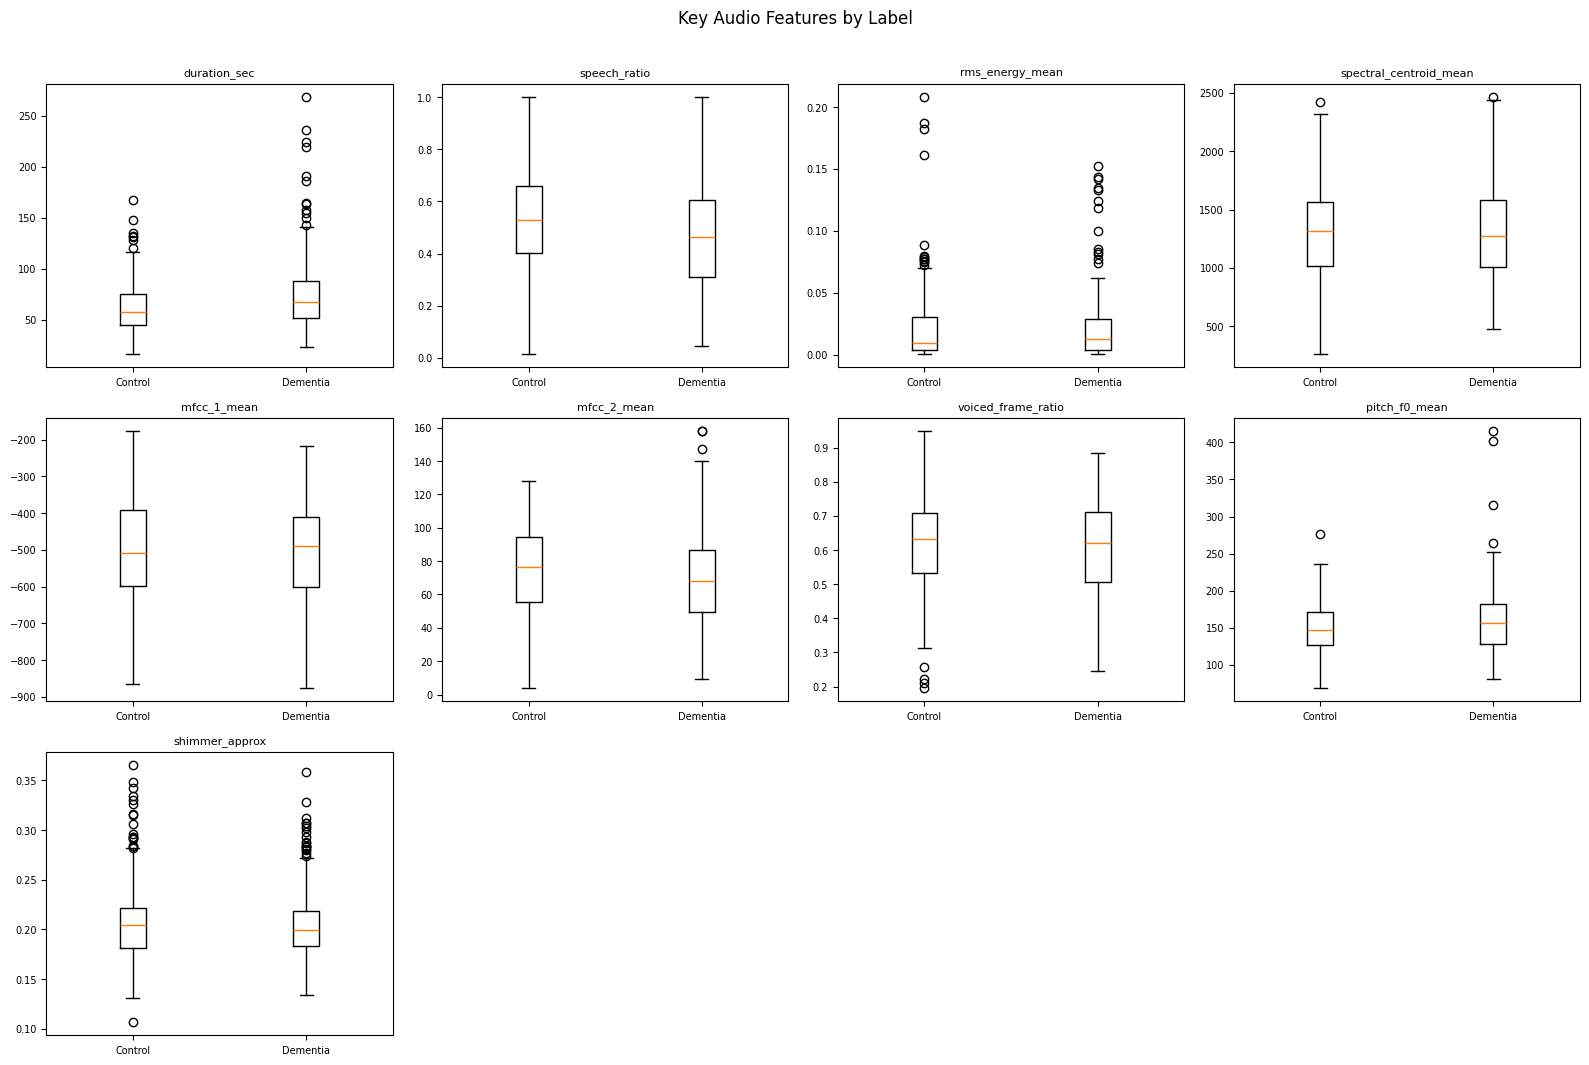

Saved: audio_feature_boxplots.png


In [14]:
key_features = [
    'duration_sec', 'pause_ratio', 'speech_ratio', 'num_pauses',
    'rms_energy_mean', 'rms_dynamic_range',
    'spectral_centroid_mean', 'mfcc_1_mean', 'mfcc_2_mean',
    'voiced_frame_ratio', 'pitch_f0_mean', 'shimmer_approx',
]

plot_cols = [f for f in key_features if f in audio_features_clean.columns]
n_cols = 4
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes_flat = axes.ravel()

for i, feat in enumerate(plot_cols):
    control_vals  = audio_features_clean[audio_features_clean['label']=='Control'][feat].dropna()
    dementia_vals = audio_features_clean[audio_features_clean['label']=='Dementia'][feat].dropna()
    axes_flat[i].boxplot([control_vals, dementia_vals], labels=['Control','Dementia'])
    axes_flat[i].set_title(feat, fontsize=8)
    axes_flat[i].tick_params(labelsize=7)

for j in range(len(plot_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Key Audio Features by Label', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'audio_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audio_feature_boxplots.png')


## 15. Save audio feature dataset

In [15]:
audio_features_clean.to_csv(AUDIO_FEATURES_OUTPUT_PATH, index=False, encoding='utf-8')
print('Saved:', AUDIO_FEATURES_OUTPUT_PATH.resolve())
print('Shape:', audio_features_clean.shape)


Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\data\processed\audio_features_dataset.csv
Shape: (552, 332)


## 16. Save feature extraction metadata

In [16]:
feature_columns = feature_cols_pruned

metadata = {
    'dataset'               : 'DementiaBank Pitt Cookie Theft',
    'input_type'            : 'audio/mp3',
    'target_sample_rate'    : TARGET_SR,
    'n_mfcc'                : N_MFCC,
    'n_mels'                : N_MELS,
    'hop_length'            : HOP_LENGTH,
    'frame_length'          : FRAME_LENGTH,
    'use_pitch'             : USE_PITCH,
    'anti_overfitting'      : {
        'correlation_threshold': CORR_THRESHOLD,
        'features_before_pruning': len(feature_cols_raw),
        'features_after_pruning' : len(feature_cols_pruned),
        'features_removed'       : len(feature_cols_raw) - len(feature_cols_pruned),
    },
    'feature_groups'        : [
        'Duration', 'RMS Energy (percentiles + dynamic range)',
        'Zero-Crossing Rate', 'Spectral Features (centroid, bandwidth, rolloff, flatness, flux, contrast)',
        f'{N_MFCC} MFCCs (mean, std, median)',
        f'{N_MFCC} MFCC Deltas (mean, std)',
        f'{N_MFCC} MFCC Delta-Deltas (mean, std)',
        'Mel-Spectrogram (4 grouped bands + profile stats)',
        'Chroma (12 bins)', 'Tonnetz (6 features)',
        'Advanced Pause Analysis', 'Jitter/Shimmer Approximation', 'Pitch/F0'
    ],
    'num_rows'              : int(audio_features_clean.shape[0]),
    'num_feature_columns'   : int(len(feature_columns)),
    'feature_columns'       : feature_columns,
    'output_file'           : str(AUDIO_FEATURES_OUTPUT_PATH),
    'clinical_note'         : 'Research-based dementia risk screening only. Not a clinical diagnosis.',
}

meta_path = REPORT_DIR / 'audio_feature_extraction_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved metadata:', meta_path.resolve())
print(f'Total feature columns (after pruning): {len(feature_columns)}')


Saved metadata: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\audio_feature_extraction_metadata.json
Total feature columns (after pruning): 318
